<a href="https://colab.research.google.com/github/ramosrabelo-ia/Hello_World/blob/main/graficos_corrigidos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Correção dos Gráficos — Prova

**Autora:** Luana — FIAP, Data Science

Cada gráfico original apresentava ao menos um erro técnico, semântico ou de uso de
ferramenta. Este notebook reconstrói os gráficos seguindo boas práticas de visualização
(Cleveland & McGill, 1984; Tufte, 2001).

## 1. Carregamento e configuração geral

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset_prova.csv")

sns.set_theme(style="whitegrid", context="notebook")
PALETA = "Set2"  # paleta qualitativa, cores distinguíveis

df.head()

,Setor,Idade,Experiência (anos),Salário (R$),Horas de Trabalho/Semana,Satisfação (1-5)
0,RH,39,18,9225.487461,38.423171,4
1,Financeiro,47,29,11436.227507,30.729479,5
2,Vendas,55,37,7363.555229,49.364169,4
3,RH,31,11,14661.384993,35.313320,2
4,RH,57,36,14549.367539,58.213758,2


## 2. Imagem 1 — Painel de 5 gráficos corrigido

**Correções aplicadas:**
- *Funcionários por Setor*: histograma → **barras** (Setor é categórico).
- *Setor × Satisfação*: scatter ilegível → **boxplot**.
- *Salário por Setor*: linha (sugere série temporal) → **barras com IC 95%**.
- *Variação Salarial*: boxplot + pontos individuais (contexto).
- *Idade × Salário*: barras coloridas confusas → **scatter com linha de tendência**.

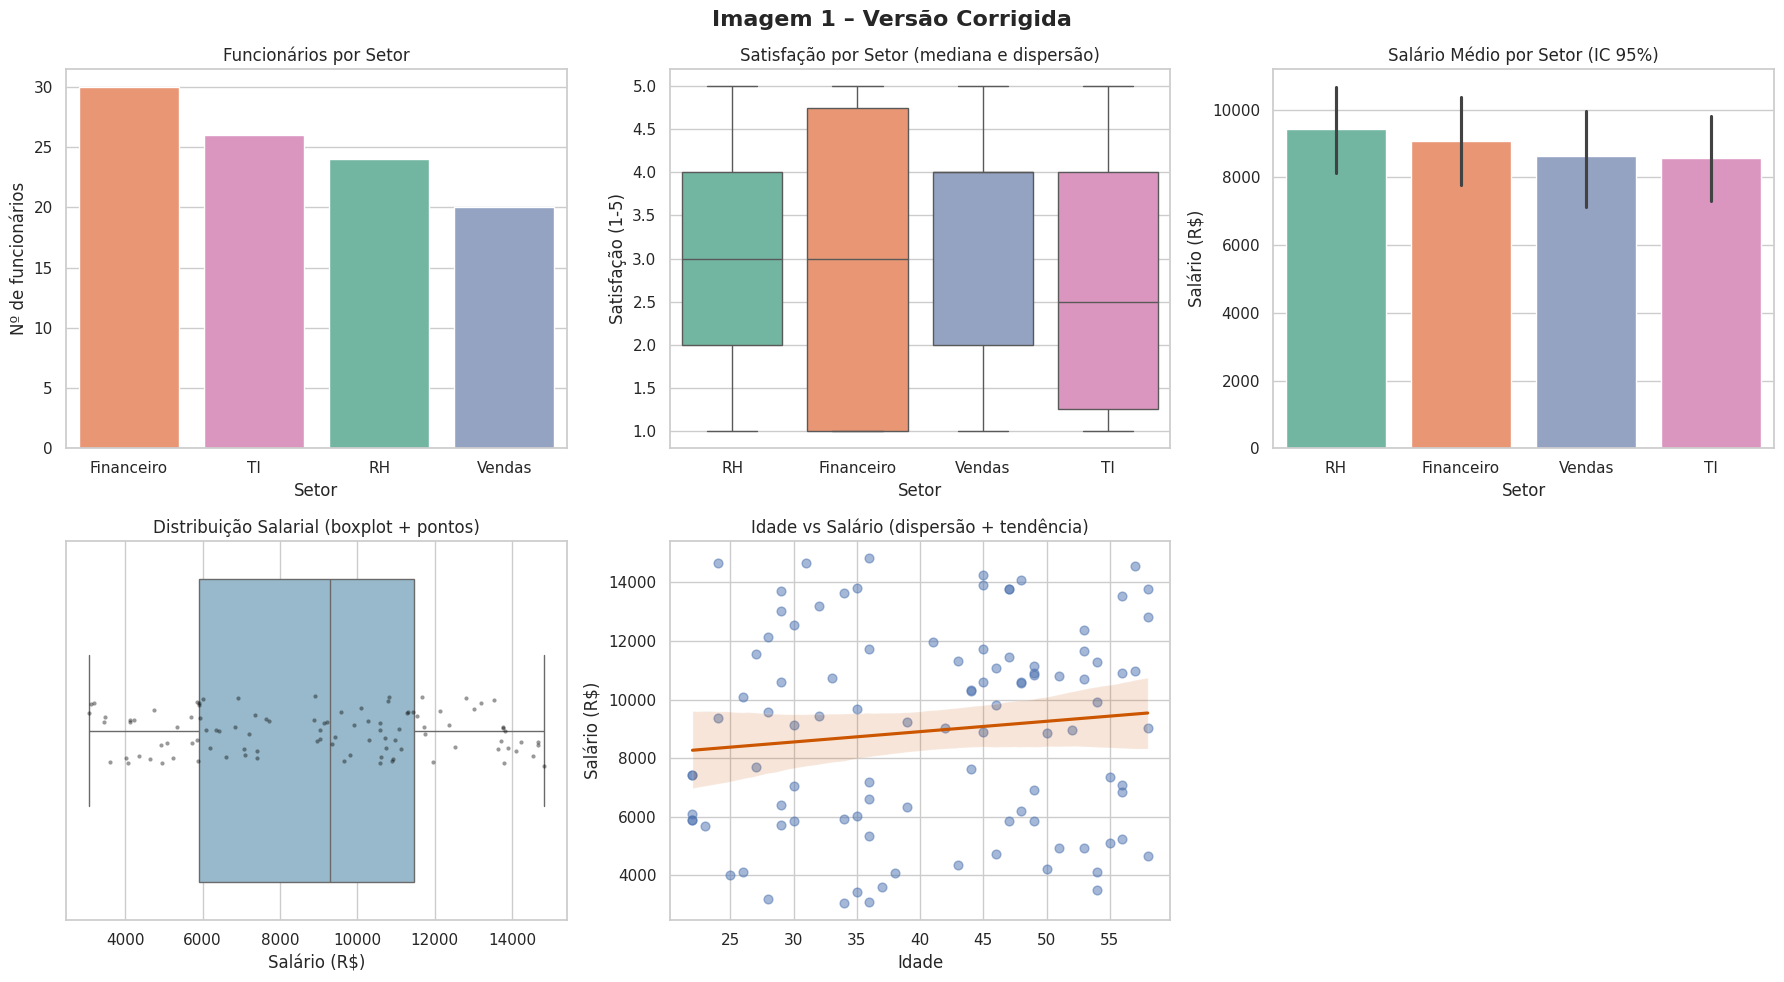

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Imagem 1 – Versão Corrigida", fontsize=16, fontweight="bold")

# (1) Funcionários por Setor
ordem = df["Setor"].value_counts().index
sns.countplot(data=df, x="Setor", order=ordem,
              hue="Setor", palette=PALETA, legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Funcionários por Setor")
axes[0, 0].set_ylabel("Nº de funcionários")

# (2) Satisfação por Setor
sns.boxplot(data=df, x="Setor", y="Satisfação (1-5)",
            hue="Setor", palette=PALETA, legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Satisfação por Setor (mediana e dispersão)")

# (3) Salário médio por Setor
sns.barplot(data=df, x="Setor", y="Salário (R$)", estimator="mean",
            errorbar=("ci", 95), hue="Setor", palette=PALETA,
            legend=False, ax=axes[0, 2])
axes[0, 2].set_title("Salário Médio por Setor (IC 95%)")

# (4) Distribuição Salarial
sns.boxplot(data=df, x="Salário (R$)", color="#8fbcd4", ax=axes[1, 0])
sns.stripplot(data=df, x="Salário (R$)", color="black",
              alpha=0.4, size=3, ax=axes[1, 0])
axes[1, 0].set_title("Distribuição Salarial (boxplot + pontos)")

# (5) Idade vs Salário
sns.regplot(data=df, x="Idade", y="Salário (R$)",
            scatter_kws={"alpha": 0.5, "s": 40},
            line_kws={"color": "#cc5500"}, ax=axes[1, 1])
axes[1, 1].set_title("Idade vs Salário (dispersão + tendência)")

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

### Leitura da Imagem 1

Financeiro é o setor mais populoso (30 pessoas) e concentra a satisfação mais alta,
enquanto TI tem a pior satisfação (mediana 2,5). Os salários médios são praticamente
iguais entre setores (R$ 8,5k–9,4k) e os intervalos de confiança se sobrepõem — a
"diferença salarial por setor" do gráfico original era ruído amostral. A dispersão
Idade × Salário mostra tendência quase plana: idade praticamente não explica salário.

## 3. Imagem 2 — Substituição da pizza

**Erro do original:** pizza esconde a variância interna de cada setor e o olho humano
compara mal ângulos (Cleveland & McGill, 1984). Substituo por (a) barras da soma e
(b) boxplot da distribuição individual.

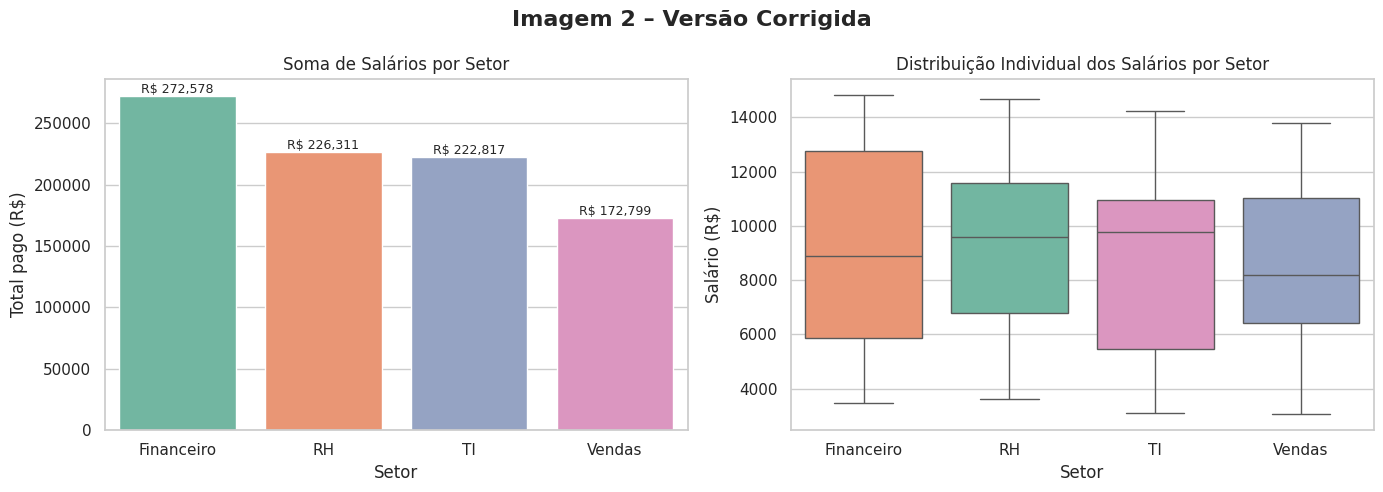

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Imagem 2 – Versão Corrigida", fontsize=16, fontweight="bold")

soma_por_setor = df.groupby("Setor")["Salário (R$)"].sum().sort_values(ascending=False)
sns.barplot(x=soma_por_setor.index, y=soma_por_setor.values,
            hue=soma_por_setor.index, palette=PALETA, legend=False, ax=axes[0])
axes[0].set_title("Soma de Salários por Setor")
axes[0].set_ylabel("Total pago (R$)")
for i, v in enumerate(soma_por_setor.values):
    axes[0].text(i, v, f"R$ {v:,.0f}", ha="center", va="bottom", fontsize=9)

sns.boxplot(data=df, x="Setor", y="Salário (R$)",
            order=soma_por_setor.index,
            hue="Setor", palette=PALETA, legend=False, ax=axes[1])
axes[1].set_title("Distribuição Individual dos Salários por Setor")

plt.tight_layout()
plt.show()

### Leitura da Imagem 2

Financeiro paga mais no total (R$ 272k) porque tem mais gente, não porque paga melhor.
O boxplot confirma: as medianas dos 4 setores estão coladas em ~R$ 9k e os intervalos
se sobrepõem totalmente. "Fatia maior da pizza" ≠ "setor mais bem remunerado".

## 4. Imagem 3 — Painel de 4 gráficos corrigido

**Correções aplicadas:**
- *Salário por Setor*: mantido (estava correto).
- *Idade × Experiência*: mantido + linha de tendência.
- *Horas por Setor*: histograma empilhado (difícil comparar) → **boxplot**.
- *Salário por Satisfação*: linha (sugere continuidade em escala ordinal 1–5) → **boxplot**.

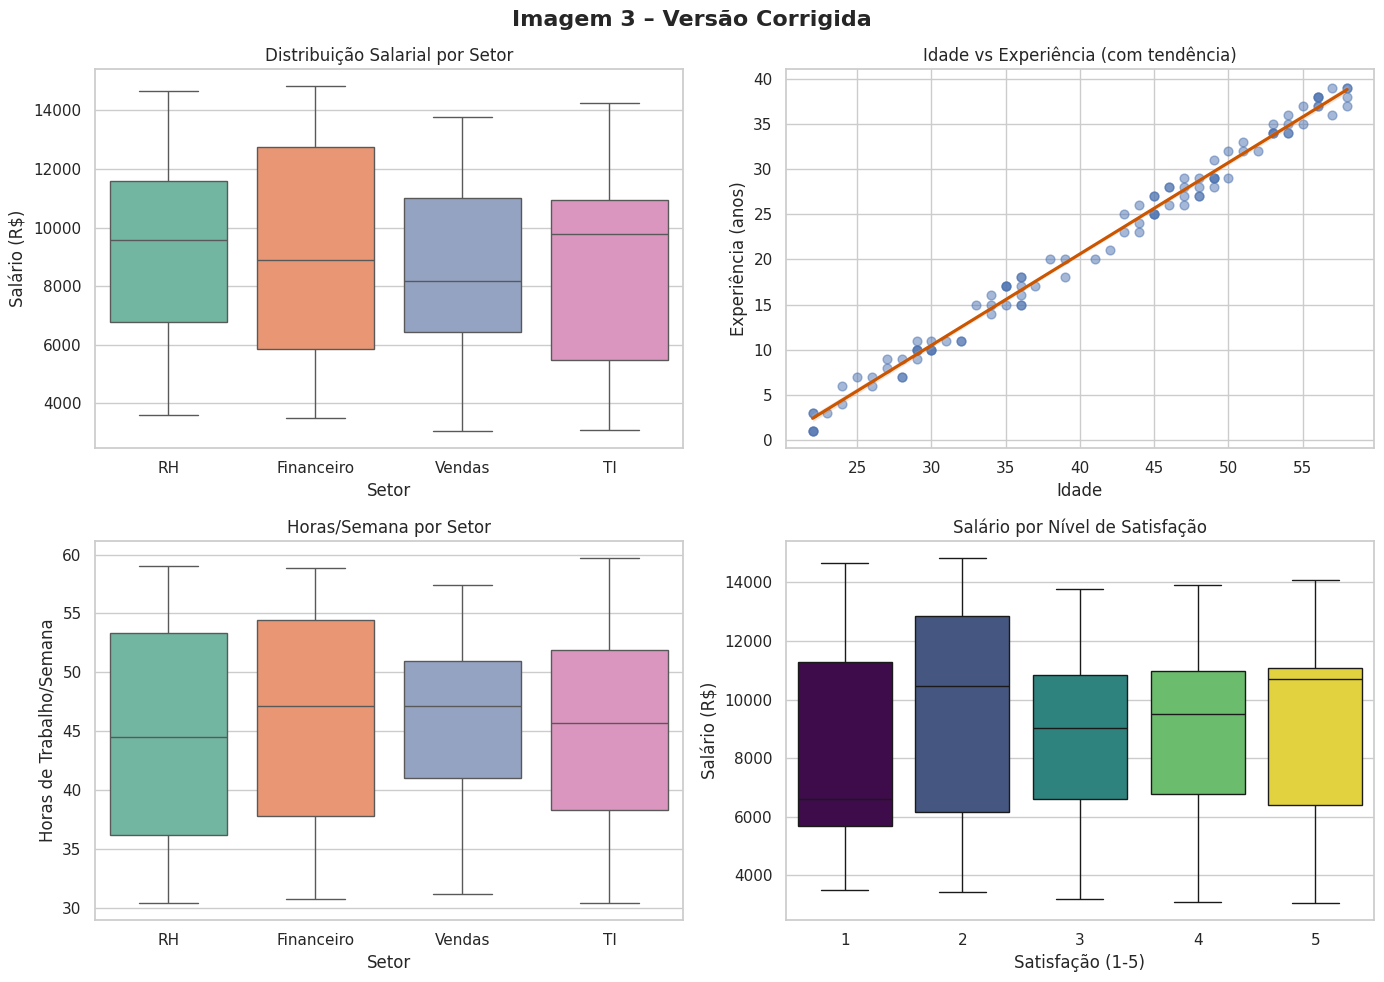

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Imagem 3 – Versão Corrigida", fontsize=16, fontweight="bold")

# (1) Salário por Setor
sns.boxplot(data=df, x="Setor", y="Salário (R$)",
            hue="Setor", palette=PALETA, legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Distribuição Salarial por Setor")

# (2) Idade vs Experiência
sns.regplot(data=df, x="Idade", y="Experiência (anos)",
            scatter_kws={"alpha": 0.5, "s": 40},
            line_kws={"color": "#cc5500"}, ax=axes[0, 1])
axes[0, 1].set_title("Idade vs Experiência (com tendência)")

# (3) Horas por Setor
sns.boxplot(data=df, x="Setor", y="Horas de Trabalho/Semana",
            hue="Setor", palette=PALETA, legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Horas/Semana por Setor")

# (4) Salário por Satisfação
sns.boxplot(data=df, x="Satisfação (1-5)", y="Salário (R$)",
            hue="Satisfação (1-5)", palette="viridis",
            legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Salário por Nível de Satisfação")

plt.tight_layout()
plt.show()

### Leitura da Imagem 3

Idade e Experiência têm correlação quase perfeita (r ≈ 0,99) — único sinal forte do
dataset. Horas trabalhadas são homogêneas entre setores (medianas 44–47h, caixas
sobrepostas). Salário por Satisfação não tem padrão monotônico: nível 2 tem mediana
mais alta que nível 5 — a satisfação não é explicada pelo salário nesses dados.